In [1]:
!pip install torch==2.1.2 transformers==4.36.2 scikit-learn pandas sentencepiece

ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==2.1.2


In [4]:
!python train.py

Loading dataset...
Train: 8375
Dev: 2094
After oversampling: 9566
Loading weights: 100% 197/197 [00:00<00:00, 1149.24it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized bec

In [5]:
!zip best_model.zip /content/BestModel/checkpoint_stage2/best_model.pt

  adding: content/BestModel/checkpoint_stage2/best_model.pt (deflated 11%)


In [18]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ======================
# CONFIG
# ======================
MODEL_NAME = "roberta-base"
MAX_LENGTH = 128
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_THRESHOLD = 0.73  # from your training log

# ======================
# LOAD DATA
# ======================
df = pd.read_csv(
    "data/dontpatronizeme_pcl.tsv",
    sep="\t",
    skiprows=4,
    header=None,
    names=["par_id","art_id","keyword","country","text","orig_label"]
)

df["orig_label"] = pd.to_numeric(df["orig_label"], errors="coerce").fillna(0).astype(int)
df["label"] = df["orig_label"].apply(lambda x: 0 if x in (0,1) else 1)

dev_ids = set(pd.read_csv("data/dev_semeval_parids-labels.csv")["par_id"])
dev_df = df[df["par_id"].isin(dev_ids)].reset_index(drop=True)

dev_df["text"] = dev_df["text"].astype(str)

# ======================
# DATASET
# ======================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PCLDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

dev_dataset = PCLDataset(dev_df["text"].tolist(), dev_df["label"].tolist())
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)

# ======================
# LOAD SAVED MODEL
# ======================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.load_state_dict(torch.load("BestModel/checkpoint_stage2/best_model.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

# ======================
# RECOMPUTE DEV PROBS
# ======================
probs = []

with torch.no_grad():
    for batch in dev_loader:
        batch = {k: v.to(DEVICE) for k,v in batch.items()}
        outputs = model(**batch)
        p = torch.softmax(outputs.logits, dim=1)[:,1]
        probs.extend(p.cpu().numpy())

# ======================
# WRITE CORRECT DEV.TXT
# ======================
final_preds = (np.array(probs) >= BEST_THRESHOLD).astype(int)

with open("BestModel/dev.txt", "w") as f:
    for p in final_preds:
        f.write(str(p) + "\n")

print("Corrected dev.txt written.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Corrected dev.txt written.


In [23]:
import pandas as pd
import numpy as np

# ================================
# REBUILD DEV SET EXACTLY LIKE TRAINING
# ================================

df = pd.read_csv(
    "data/dontpatronizeme_pcl.tsv",
    sep="\t",
    skiprows=4,
    header=None,
    names=["par_id","art_id","keyword","country","text","orig_label"]
)

df["orig_label"] = pd.to_numeric(df["orig_label"], errors="coerce").fillna(0).astype(int)
df["label"] = df["orig_label"].apply(lambda x: 0 if x in (0,1) else 1)
df["text"] = df["text"].astype(str)

dev_ids = set(pd.read_csv("data/dev_semeval_parids-labels.csv")["par_id"])
dev_df = df[df["par_id"].isin(dev_ids)].reset_index(drop=True)

# ================================
# LOAD PREDICTIONS
# ================================
with open("BestModel/dev.txt") as f:
    preds = [int(x.strip()) for x in f.readlines()]

if len(preds) != len(dev_df):
    raise ValueError("Prediction length mismatch.")

dev_df["pred"] = preds
dev_df["true"] = dev_df["label"]

# ================================
# ERROR ANALYSIS
# ================================
errors = dev_df[dev_df["pred"] != dev_df["true"]]

print("\nTotal Dev Samples:", len(dev_df))
print("Total Errors:", len(errors))
print("Error Rate:", round(len(errors)/len(dev_df), 4))

print("\nFALSE POSITIVES (Pred=1, True=0):")
fp = errors[(errors["pred"] == 1) & (errors["true"] == 0)]
display(fp[["text"]].head(5))

print("\nFALSE NEGATIVES (Pred=0, True=1):")
fn = errors[(errors["pred"] == 0) & (errors["true"] == 1)]
display(fn[["text"]].head(5))


Total Dev Samples: 2094
Total Errors: 174
Error Rate: 0.0831

FALSE POSITIVES (Pred=1, True=0):


,text
169,Marcos said the government should help poor fa...
207,As she descended into a state of hopelessness ...
228,""" This incident will not tear us down but rath..."
252,"So , let the NPP government appointees look do..."
254,""" So we do need to heal ourselves as an Aborig..."



FALSE NEGATIVES (Pred=0, True=1):


,text
1,Krueger recently harnessed that creativity to ...
2,10:41am - Parents of children who died must ge...
4,We are alarmed to learn of your recently circu...
8,""" People do n't understand the hurt , people d..."
9,He depicts demonstrations by refugees at the b...


              precision    recall  f1-score   support

           0     0.9624    0.9451    0.9537      1895
           1     0.5536    0.6482    0.5972       199

    accuracy                         0.9169      2094
   macro avg     0.7580    0.7967    0.7754      2094
weighted avg     0.9235    0.9169    0.9198      2094



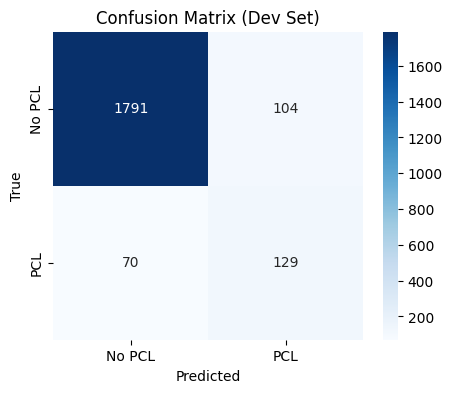

In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# REBUILD DEV SET EXACTLY LIKE TRAINING
# ================================

df = pd.read_csv(
    "data/dontpatronizeme_pcl.tsv",
    sep="\t",
    skiprows=4,
    header=None,
    names=["par_id","art_id","keyword","country","text","orig_label"]
)

df["orig_label"] = pd.to_numeric(df["orig_label"], errors="coerce").fillna(0).astype(int)
df["label"] = df["orig_label"].apply(lambda x: 0 if x in (0,1) else 1)

dev_ids = set(pd.read_csv("data/dev_semeval_parids-labels.csv")["par_id"])
dev_df = df[df["par_id"].isin(dev_ids)].reset_index(drop=True)

# ================================
# LOAD PREDICTIONS
# ================================
with open("BestModel/dev.txt") as f:
    preds = [int(x.strip()) for x in f.readlines()]

if len(preds) != len(dev_df):
    raise ValueError("Prediction length mismatch.")

dev_df["pred"] = preds
y_true = dev_df["label"]
y_pred = dev_df["pred"]

# ================================
# METRICS
# ================================
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No PCL", "PCL"],
            yticklabels=["No PCL", "PCL"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Dev Set)")
plt.show()